In [29]:
import numpy as np
import pandas as pd
from matplotlib import pylab as plt
metadata_file = '/Users/fmcc0003/issm/projects/ISMIP6Hackathon/GroupTFtoOcean/data_analysis/Metadata_icefront.txt'
df_info = pd.read_csv(metadata_file)

computed_name = 'ComputedScalarsHelene'
mnt_pth = '/Volumes/FMac/computing/data/antarctica/' #mount path
pth_ismip6hack= mnt_pth + 'ismip6/hackathon/ComputedScalars/' #write folder
pth_ismip6 =mnt_pth + 'ismip6/hackathon/' #read folder
pth_helene =mnt_pth + 'ismip6/hackathon/ComputedScalarsHelene/'
pth_table = '/Users/fmcc0003/issm/projects/ISMIP6Hackathon/GroupBMBtodSLR/data_analysis/tables/'

### Get all the data

In [30]:
colors = ['#1f77b4','#2ca02c','#9467bd']
colors2 = ['darksalmon','coral','olive']
scatters = ['.','+','^','v']

df_dils = pd.read_csv('tables/prmse_recalc_linear_dynamic_ice_loss_sensitivity_from_cumBMB.csv')

regions = df_dils.columns[4:].values.tolist()
regions = ['AIS', 'Amundsen', 'Ross', 'FilchnerRonne', 'Aurora', 'Wilkes']
regions_all= regions.copy()
regions1 = regions[1:]
regions_all1=regions1.copy()

experiments = np.unique(df_dils["Experiment"])
df_exp = df_dils[df_dils['Experiment']== experiments[0]].reset_index(drop=True)
models = df_exp.Model.values

df_best = df_exp.copy()
df_best['mean-error']=1e15
df_best = df_best.drop(df_best.columns[0:2],axis=1)
#df_best = df_best.drop(df_best.columns[1],axis=1)
df_best = df_best.drop(df_best.columns[1:11],axis=1)
for region in regions:
    df_best[f'dils_{region}']=0
    df_best[f'dils_std_{region}']=0
    df_best[f'dils_min_{region}']=0
    df_best[f'dils_max_{region}']=0
    df_best['parameterization']=''

In [31]:
df_dils

,Unnamed: 0,Experiment,Model,Path,AIS,Amundsen,Ross,FilchnerRonne,WestAntarctica,EastAntarctica,Peninsula,Aurora,Wilkes
0,0,expAE02,DC_ISSM,/Volumes/FMac/computing/data/antarctica/ismip6...,0.708013,0.880399,0.963274,0.994620,0.679396,0.742261,5.379338,0.138431,0.617616
1,1,expAE02,IGE_ElmerIce,/Volumes/FMac/computing/data/antarctica/ismip6...,0.591994,1.362037,0.623237,0.670602,0.579709,0.631205,4.584802,0.446351,1.846539
2,2,expAE02,ILTS_SICOPOLIS,/Volumes/FMac/computing/data/antarctica/ismip6...,0.681681,0.566149,1.296886,0.326122,0.543756,0.775789,1.649635,0.373096,1.827393
3,3,expAE02,LSCE_GRISLI2,/Volumes/FMac/computing/data/antarctica/ismip6...,1.186116,1.931780,1.100571,1.231573,0.997590,1.286674,2.399038,1.644647,1.634814
4,4,expAE02,LSCE_GRISLI,/Volumes/FMac/computing/data/antarctica/ismip6...,1.251244,0.419968,0.797661,0.842871,0.974524,1.742506,1.903493,1.026186,1.652115
...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,139,expAE05,VUW_PISM2,/Volumes/FMac/computing/data/antarctica/ismip6...,1.131528,0.822278,1.475005,1.163315,0.905038,1.559910,0.232484,1.021940,0.915507
140,140,expAE05,VUW_PISM2_s1,/Volumes/FMac/computing/data/antarctica/ismip6...,1.125695,1.096664,1.438390,1.076536,0.956404,1.449466,0.270682,0.979869,0.613739
141,141,expAE05,VUW_PISM2_s2,/Volumes/FMac/computing/data/antarctica/ismip6...,1.135870,0.810093,1.581837,1.199053,0.892778,1.591459,0.335190,1.174706,1.084458
142,142,expAE05,VUW_PISM2_s3,/Volumes/FMac/computing/data/antarctica/ismip6...,1.211692,1.600853,1.841978,1.366255,0.980362,1.630513,0.588082,1.120318,0.933134


In [32]:
df_best

,Model,mean-error,dils_AIS,dils_std_AIS,dils_min_AIS,dils_max_AIS,parameterization,dils_Amundsen,dils_std_Amundsen,dils_min_Amundsen,...,dils_min_FilchnerRonne,dils_max_FilchnerRonne,dils_Aurora,dils_std_Aurora,dils_min_Aurora,dils_max_Aurora,dils_Wilkes,dils_std_Wilkes,dils_min_Wilkes,dils_max_Wilkes
0,DC_ISSM,1.000000e+15,0,0,0,0,,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,IGE_ElmerIce,1.000000e+15,0,0,0,0,,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,ILTS_SICOPOLIS,1.000000e+15,0,0,0,0,,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,LSCE_GRISLI2,1.000000e+15,0,0,0,0,,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,LSCE_GRISLI,1.000000e+15,0,0,0,0,,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,NCAR_CISM1,1.000000e+15,0,0,0,0,,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,NCAR_CISM2,1.000000e+15,0,0,0,0,,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,NORCE_CISM2-MAR364-ERA-t1,1.000000e+15,0,0,0,0,,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,NORCE_CISM3-MAR364-ERA-t1-local,1.000000e+15,0,0,0,0,,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,NORCE_CISM3-MAR364-ERA-t1-nonlocal,1.000000e+15,0,0,0,0,,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [34]:
clname = df_best.columns
i_clname = np.arange(0,clname.size)

for l,df in enumerate(df_best):
    
    for i,Mod in enumerate(models):
        #iterate though model names
        best = 1e15
        dfmodel = df_dils[df_dils['Model']== Mod].copy()
    
        for j,region in enumerate(regions):
            mdn = np.nanmedian(dfmodel[f'{region}'].values).copy() #get median from all 4 exp for each region
            std = np.nanstd(dfmodel[f'{region}'].values).copy() #get std from all 4 exp for each region
            df_best[f'dils_{region}'][i]=np.nanmedian(dfmodel[f'{region}'].values).copy()
            df_best[f'dils_std_{region}'][i]=np.nanstd(dfmodel[f'{region}'].values).copy()
            df_best[f'dils_min_{region}'][i]=np.nanmin(dfmodel[f'{region}'].values).copy()
            df_best[f'dils_max_{region}'][i]=np.nanmax(dfmodel[f'{region}'].values).copy()
                        
            #i_y =i_clname[clname==f'dils_{region}'][0]
            #mdn = np.nanmedian(dfmodel[f'{region}'].values).copy() #get mean from all 4 exp for one region
            #std = np.nanstd(dfmodel[f'{region}'].values).copy()
            #dfmodel[f'{region}'][i] = np.nanmedian(dfmodel[f'{region}'].values).copy() #get mean from all 4 exp for one region
            #df_best.iloc[i,j] = np.nanmedian(dfmodel[f'{region}'].values).copy()
            #df_best[f'dils_{region}']=np.nanmedian(dfmodel[f'{region}'].values).copy()
        
    # #now take again the mean for each method for all regions of interest, do not use VUW_PISMv1_s1
    # if Mod == 'VUW_PISM1_s1':
    #     mn = np.nanmean(dfmodel[regions].values[1:]).copy()
    #     std =np.nanstd(dfmodel[regions].values[1:]).copy()
    # else:
    #     mn =np.nanmean(dfmodel[regions].values).copy()
    #     std =np.nanstd(dfmodel[regions].values).copy()
    
    # df_best.iloc[i,1] = mn #get mininimum of the means 
    # #df_best.iloc[i,1] = np.min([df_best.iloc[i,1],mn]).copy() #get mininimum of the means 
    # if df_best.iloc[i,1] == mn:
    #     #assign method if minimum is written in in the data frame:
    #     df_best.iloc[i,2]=dfs_string[l]
        
    # df_info_model = df_info[df_info['fileID']==df.iloc[i].Model ]
    # df_info_model_exp = df_info_model[df_info_model['Experiment']==experiments[0]]
    # meltparam =  df_info_model_exp['Melt parameterisation'].values[0]
    # df_best.iloc[i,3]= meltparam
    # meth = df_best.iloc[i,2].split('_')[-1]
    # icefront =  df_info_model_exp['ice front'].values[0]

regions_all.append('mean-error')
df_best.to_csv('tables/best_dils_per_model.csv')

/var/folders/v3/r3qsjbkx2gl_9r5s_n0726wxcg0fz6/T/ipykernel_21494/4000120774.py:14: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_best[f'dils_{region}'][i]=np.nanmedian(dfmodel[f'{region}'].values).copy()
/var/folders/v3/r3qsjbkx2gl_9r5s_n

## Plot the main figure

### Creates the mins and max from the methods 

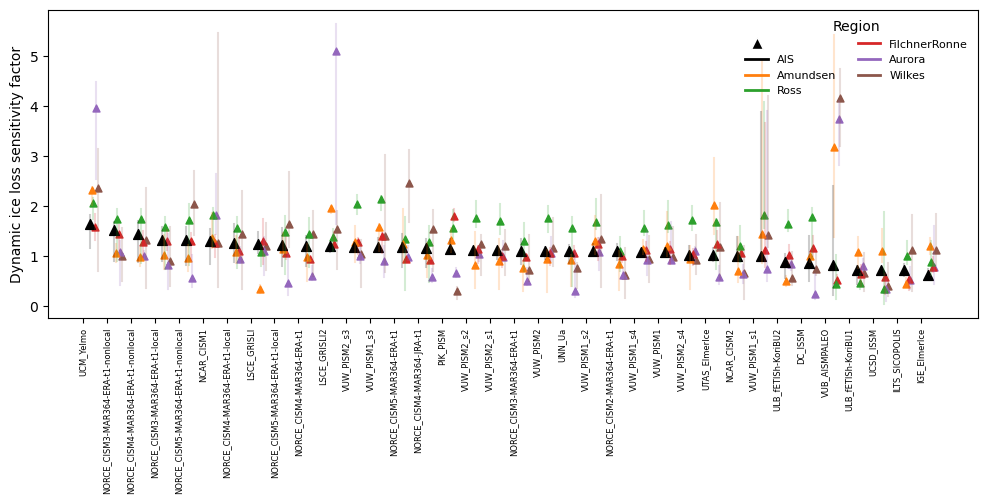

In [39]:
index =np.argsort(df_best['dils_AIS'].values)
index = index[::-1]

param_u = np.unique(df_best['parameterization'])
marker_u = ['^','v','*','s','P','p']
dic_marker = {}
for i,key in enumerate(param_u):
    dic_marker[key]= marker_u[i]
markers = []
marker_nomodel=[]
msk = df_best.Model.values != 'VUW_PISM2_s1'
for key in df_best['parameterization'][index]:
    markers.append(dic_marker[key])

for key in df_best['parameterization'][msk]:
    marker_nomodel.append(dic_marker[key])

f,ax = plt.subplots(1,1,figsize =(12,4))
colors = ['black', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

for i,region in enumerate(regions[::-1]):
    y = df_best[f'dils_{region}'].values[index]
    y_err_lower = df_best[f'dils_min_{region}'].values[index]
    y_err_upper = df_best[f'dils_max_{region}'].values[index] 
    #y_err_lower = df_best_min_max[f'min_dils_{region}'].values[index]
    #y_err_upper = df_best_min_max[f'max_dils_{region}'].values[index] 
    xall = np.arange(len(index))*8+5 -0.5 *i
    
    for j, yl in enumerate(y_err_lower):
        yu = y_err_upper[j]
        ym = y[j]
        x=xall[j]
        if i == 5:
            plt.scatter(x, ym, marker=markers[j], color=colors[::-1][i], s=50)
        else:
            plt.scatter(x, ym, marker=markers[j], color=colors[::-1][i], s=25)
        plt.plot([x,x], [yl,yu], color=colors[::-1][i], alpha=0.2)
        
ax.set_xticks(np.arange(len(index))*8)
ax.set_xticklabels(df_best['Model'].values[index], rotation = 90,fontsize =6)
ax.set_ylabel('Dynamic ice loss sensitivity factor') ##TODO: Check units

# Legend for markers
marker_handles = [plt.Line2D([0], [0], marker=marker_u[i], color='w', 
                             markerfacecolor='k', markersize=8, 
                             label=param_u[i]) 
                  for i in range(len(param_u))]

# Legend for colors
color_handles = [plt.Line2D([0], [0], color=colors[i], lw=2, 
                            label=region) 
                 for i, region in enumerate(regions)]

# Combine marker and color legends into one
combined_handles = marker_handles + color_handles
combined_labels = param_u.tolist() + regions

# Add the combined legend
ax.legend(handles=combined_handles, labels=combined_labels, title="Region", 
          loc='upper right', bbox_to_anchor=(1, 1), ncol=2, frameon=False, fontsize = 8)

# Your existing code here...

# Save the figure with tight bounding box
f.savefig('/Volumes/FMac/computing/data/antarctica/ismip6/hackathon/figures/dils_region.pdf', bbox_inches='tight')
f.savefig('/Volumes/FMac/computing/data/antarctica/ismip6/hackathon/figures/dils_region.jpeg', bbox_inches='tight')


In [ ]:
df_best_min_max = df_best.copy()

In [ ]:
index =np.argsort(df_best['dils_AIS'].values)
index = index[::-1]
for region in regions:
    df_best_min_max[f'max_dils_{region}']=0
    df_best_min_max[f'min_dils_{region}']=0

In [ ]:
for l,df in enumerate(df_best):
    for i,Mod in enumerate(models):
        mn = np.nanmean(dfmodel[f'{region}'].values).copy() #get mean from all 4 exp for one region
        std = np.nanstd(dfmodel[f'{region}'].values).copy()
        #now take again the mean for each method of all reions of interest, do not use VUW_PISMv1_s1
        if Mod == 'VUW_PISM1_s1':
            mn = np.nanmean(dfmodel[regions].values[1:]).copy()
            std = np.nanstd(dfmodel[regions].values[1:]).copy()
        else:
            mn = np.nanmean(dfmodel[regions].values).copy()
            std = np.nanstd(dfmodel[regions].values).copy()
            df_best.iloc[i,1] = np.min([df_best.iloc[i,1],mn]).copy() #get mininimum of the means 
        if df_best.iloc[i,1] == mn:
            df_info_model = df_info[df_info['fileID']==df.iloc[i].Model ]
            df_info_model_exp = df_info_model[df_info_model['Experiment']==experiments[0]]
            meltparam =  df_info_model_exp['Melt parameterisation'].values[0]
            df_best.iloc[i,3]= meltparam
            meth = df_best.iloc[i,2].split('_')[-1]

In [ ]:
clname = df_best_min_max.columns
i_clname = np.arange(0,clname.size)

for i in range(df_best_min_max.shape[0]):
    method = df_best_min_max.iloc[i]['method']
    Model = df_best_min_max.iloc[i]['Model']
    ids =np.asarray([0,1,2])
    k = ids[method==np.asarray(dfs_string)][0]
    #df_method = df_ms_all[k]
    #df_method_Model = df_method[df_method.Model== Model]
    for region in regions:
        i_y =i_clname[clname== f'max_dils_{region}'][0]
        i_y2 =i_clname[clname== f'min_dils_{region}'][0]
        if Model == 'VUW_PISM1_s1':
            df_best_min_max.iloc[i,i_y] =df_method_Model[region].values[1:].max()
            df_best_min_max.iloc[i,i_y2] =df_method_Model[region].values[1:].min()
            print(Model)
            print(df_method_Model[region].values[1:])
        elif (Model == 'VUW_PISM1_s3') & (region == 'Wilkes'):
            df_best_min_max.iloc[i,i_y] =df_method_Model[region].values[:-1].max()
            df_best_min_max.iloc[i,i_y2] =df_method_Model[region].values[:-1].min()
            
        else:
            df_best_min_max.iloc[i,i_y] =df_method_Model[region].values.max()
            df_best_min_max.iloc[i,i_y2] =df_method_Model[region].values.min()